# Sheet Silicate (Serpentine/Saponite) Quantification Workflow

This notebook demonstrates the `StoichiometryCore` workflow for TEM-EDS quantification of serpentine/saponite (sheet silicate) grains. It walks through five progressive analysis steps:

1. **K-Factored Quantification** — raw counts to weight%/atomic% using instrument-specific k-factors
2. **Thickness Correction** — applies thin-film absorption correction (ρ·τ) and low takeoff angle
3. **Instrument Correction** — adds arbitrary absorption from the detector window
4. **Serpentine Phase Analysis** — calculates cation ratios, site occupancies, and formulas
5. **Sheet Silicate Ternary Diagrams** — visualizes composition in (Si+Al)-Fe-Mg and Tet-Oct-Inter space

## 1. Setup

Import core modules and configure matplotlib for inline rendering in Jupyter.

In [1]:
import sys
import os
import warnings
os.chdir(os.path.abspath('..'))
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import StoichiometryCore as core
import PhysicsBasics as pb

%matplotlib inline

# Suppress harmless RuntimeWarnings from AbsorptionCorrection.py
# when processing elements with zero abundance in the sample.
warnings.filterwarnings('ignore', category=RuntimeWarning, module='AbsorptionCorrection')

pd.set_option('display.precision', 4)
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)

print(f'numpy {np.__version__} | pandas {pd.__version__}')
print(f'PhysicsBasics: H={pb.H} ... Uuo={pb.Uuo} (MAXELEMENT={pb.MAXELEMENT})')

In C:\Users\zsg\.matplotlib\stylelib\scpy.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In C:\Users\zsg\.matplotlib\stylelib\scpy.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


numpy 2.3.5 | pandas 2.3.3
PhysicsBasics: H=1 ... Uuo=118 (MAXELEMENT=118)


## 2. TEM Count Data

Create a 118-element numpy vector with non-zero TEM-EDS counts for O, Mg, Si, Fe, Mn, Ni — representative of a lizardite antigorine-type serpentine with Fe-Mn-Ni substitutions, analyzed on a JEOL 2010F TEM at 80 keV.

**Note:** H is NOT included in TEM counts — it is invisible to EDS. The Serpentine phase analysis infers H from O stoichiometry using a 4/9 ratio (4 OH per 5 O in Mg₃Si₂O₅(OH)₄).

In [2]:
tem_counts = np.zeros(pb.MAXELEMENT)
tem_counts[pb.O-1]   = 50000
tem_counts[pb.Mg-1]  = 35000
tem_counts[pb.Si-1]  = 40000
tem_counts[pb.Fe-1]  = 20000
tem_counts[pb.Mn-1]  = 1500
tem_counts[pb.Ni-1]  = 800

nonzero = [(pb.ElementalSymbols[i+1], tem_counts[i]) for i in range(pb.MAXELEMENT) if tem_counts[i] > 0]
df_counts = pd.DataFrame(nonzero, columns=['Element', 'Counts'])
df_counts

,Element,Counts
0,O,50000.0
1,Mg,35000.0
2,Si,40000.0
3,Mn,1500.0
4,Fe,20000.0
5,Ni,800.0


## 3. Stoichiometry

Load the silicate stoichiometry file, which provides cation charge states for the oxygen-by-stoichiometry calculation.

In [3]:
silicate_stoich = core.load_stoichiometry('Silicates')
stoich_df = pd.DataFrame({
    'Element': pb.ElementalSymbols[1:],
    'Charge': silicate_stoich
})
stoich_df[stoich_df['Charge'] != 0]

,Element,Charge
0,H,1.0
2,Li,1.0
3,Be,2.0
4,B,3.0
5,C,4.0
6,N,-3.0
7,O,-2.0
8,F,-1.0
10,Na,1.0
11,Mg,2.0


## 4. Step 1 — K-Factored Quantification

Convert raw TEM counts to weight % and atomic % using the Titan 80 keV k-factors. Oxygen is determined by stoichiometry (oxygen-by-stoichiometry method).

In [4]:
analysis_input = core.AnalysisInput(
    values=dict(core.vector_to_element_dict(tem_counts)),
    input_type='Counts',
    stoichiometry=silicate_stoich
)

options_step1 = core.AnalysisOptions(kfactors='Titan 80 keV')
result1 = core.run_analysis(analysis_input, options=options_step1)

print(result1.report_text)

quant_df1 = pd.DataFrame(result1.tables[1].rows)
quant_df1

[1. 0. 1. 2. 3. 4. 0. 0. 0. 0. 1. 2. 3. 4. 5. 0. 0. 0. 1. 2. 3. 4. 3. 3.
 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Input data:
Element           Counts
O              50000.000
Mg             35000.000
Si             40000.000
Mn              1500.000
Fe             20000.000
Ni               800.000
Total:        147300.000

k-factors used: Titan 80 keV
Oxygen determined by stoichiometry

Quantification results:
Element       At%      Wt%  Ox Wt %  Valence k-factor
O          58.671   41.581    0.000    0.000    1.130
Mg         16.114   17.349   28.769    2.000    0.919
Si         17.341   21.574   46.155    4.000    1.000
Mn          0.517    1.258    1.624    2.000    1.555
Fe          7.056   17.454   22.454    2.000    1.618
Ni          0.

,element,at_pct,wt_pct,oxide_wt_pct,valence,k_factor
0,O,58.6707,41.5812,0.0000,0.0,1.130
1,Mg,16.1137,17.3486,28.7687,2.0,0.919
2,Si,17.3415,21.5744,46.1550,4.0,1.000
3,Mn,0.5170,1.2581,1.6244,2.0,1.555
4,Fe,7.0556,17.4537,22.4542,2.0,1.618
5,Ni,0.3016,0.7840,0.9977,2.0,1.817


## 5. Step 2 — Thickness Correction

Apply a thin-film absorption correction. For a 100 nm thick specimen with serpentine density (2.5 g/cm³): ρ·τ = 0.025 g/cm². Takeoff angle is 18° (typical TEM geometry).

In [5]:
options_step2 = core.AnalysisOptions(
    kfactors='Titan 80 keV',
    absorption_correction=-0.025,
    takeoff=18.0
)
result2 = core.run_analysis(analysis_input, options=options_step2)

print(result2.report_text)

quant_df2 = pd.DataFrame(result2.tables[1].rows)

# Comparison vs Step 1
comparison2 = quant_df2[['element']].copy()
comparison2['Step1 At%'] = quant_df1.set_index('element').loc[comparison2['element'], 'at_pct'].values
comparison2['Step2 At%'] = quant_df2['at_pct']
comparison2['Δ At%'] = (comparison2['Step2 At%'] - comparison2['Step1 At%']).round(4)
comparison2['Step1 Wt%'] = quant_df1.set_index('element').loc[comparison2['element'], 'wt_pct'].values
comparison2['Step2 Wt%'] = quant_df2['wt_pct']
comparison2['Δ Wt%'] = (comparison2['Step2 Wt%'] - comparison2['Step1 Wt%']).round(4)
comparison2

Loading CXRO Scattering Files/o.nff
Loading CXRO Scattering Files/mg.nff
Loading CXRO Scattering Files/si.nff
Loading CXRO Scattering Files/mn.nff
Loading CXRO Scattering Files/fe.nff
Loading CXRO Scattering Files/ni.nff
[1. 0. 1. 2. 3. 4. 0. 0. 0. 0. 1. 2. 3. 4. 5. 0. 0. 0. 1. 2. 3. 4. 3. 3.
 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Input data:
Element           Counts
O              50000.000
Mg             35000.000
Si             40000.000
Mn              1500.000
Fe             20000.000
Ni               800.000
Total:        147300.000

k-factors used: Titan 80 keV
Absorption Correction: -25.000000 nm*g/cm3
Takeoff angle: 18.00 degrees
Oxygen determined by stoichiometry

Quantification results:
Element       At%      Wt%  Ox Wt %  Valence 

,element,Step1 At%,Step2 At%,Δ At%,Step1 Wt%,Step2 Wt%,Δ Wt%
0,O,58.6707,58.6734,0.0026,41.5812,41.5530,-0.0282
1,Mg,16.1137,16.0540,-0.0597,17.3486,17.2718,-0.0768
2,Si,17.3415,17.3467,0.0053,21.5744,21.5654,-0.0091
3,Mn,0.5170,0.5203,0.0034,1.2581,1.2653,0.0073
4,Fe,7.0556,7.1021,0.0465,17.4537,17.5560,0.1023
5,Ni,0.3016,0.3035,0.0019,0.7840,0.7885,0.0045


## 6. Step 3 — Instrument Correction

Add the arbitrary absorption correction for the Titan detector window, on top of the thickness correction. This accounts for low-energy X-ray absorption in the detector filter/window before the X-rays reach the detector.

In [6]:
options_step3 = core.AnalysisOptions(
    kfactors='Titan 80 keV',
    absorption_correction=-0.025,
    arbitrary_absorption='Titan Detector Window',
    takeoff=18.0
)
result3 = core.run_analysis(analysis_input, options=options_step3)

print(result3.report_text)

quant_df3 = pd.DataFrame(result3.tables[1].rows)

# Full comparison across all three quantification steps
comparison3 = quant_df3[['element']].copy()
comparison3['Step1 At%'] = quant_df1.set_index('element').loc[comparison3['element'], 'at_pct'].values
comparison3['Step2 At%'] = quant_df2.set_index('element').loc[comparison3['element'], 'at_pct'].values
comparison3['Step3 At%'] = quant_df3['at_pct']
comparison3['Step1 Wt%'] = quant_df1.set_index('element').loc[comparison3['element'], 'wt_pct'].values
comparison3['Step2 Wt%'] = quant_df2.set_index('element').loc[comparison3['element'], 'wt_pct'].values
comparison3['Step3 Wt%'] = quant_df3['wt_pct']
comparison3

Loading CXRO Scattering Files/be.nff
Loading CXRO Scattering Files/b.nff
Loading CXRO Scattering Files/c.nff
Loading CXRO Scattering Files/n.nff
Loading CXRO Scattering Files/al.nff
Titan Detector Window
[1. 0. 1. 2. 3. 4. 0. 0. 0. 0. 1. 2. 3. 4. 5. 0. 0. 0. 1. 2. 3. 4. 3. 3.
 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Input data:
Element           Counts
O              50000.000
Mg             35000.000
Si             40000.000
Mn              1500.000
Fe             20000.000
Ni               800.000
Total:        147300.000

Arbitrary Absorption Correction used: Titan Detector Window
k-factors used: Titan 80 keV
Absorption Correction: -25.000000 nm*g/cm3
Takeoff angle: 18.00 degrees
Oxygen determined by stoichiometry

Quantification results:
El

,element,Step1 At%,Step2 At%,Step3 At%,Step1 Wt%,Step2 Wt%,Step3 Wt%
0,O,58.6707,58.6734,58.6414,41.5812,41.5530,41.6021
1,Mg,16.1137,16.0540,16.2741,17.3486,17.2718,17.5387
2,Si,17.3415,17.3467,17.2827,21.5744,21.5654,21.5229
3,Mn,0.5170,0.5203,0.5124,1.2581,1.2653,1.2481
4,Fe,7.0556,7.1021,6.9909,17.4537,17.5560,17.3110
5,Ni,0.3016,0.3035,0.2986,0.7840,0.7885,0.7771


## 7. Step 4 — Serpentine Phase Analysis

Run the Serpentine ideal phase analysis plugin, which calculates:
- Cation ratios (Mg/(Mg+Fe), Al/(Al+Si), element/Octahedral)
- Octahedral and tetrahedral atoms per 18 atoms
- Serpentine formula: Oct₃ Tet₂ O₉ H₄ = Mg₃Si₂O₅(OH)₄

H is inferred from O stoichiometry using the 4/9 ratio (4 OH per 5 O).

In [7]:
options_step4 = core.AnalysisOptions(
    kfactors='Titan 80 keV',
    absorption_correction=-0.025,
    arbitrary_absorption='Titan Detector Window',
    takeoff=18.0,
    phase_analysis='Serpentine'
)
result4 = core.run_analysis(analysis_input, options=options_step4)

print(result4.report_text)

Titan Detector Window
[1. 0. 1. 2. 3. 4. 0. 0. 0. 0. 1. 2. 3. 4. 5. 0. 0. 0. 1. 2. 3. 4. 3. 3.
 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Input data:
Element           Counts
O              50000.000
Mg             35000.000
Si             40000.000
Mn              1500.000
Fe             20000.000
Ni               800.000
Total:        147300.000

Arbitrary Absorption Correction used: Titan Detector Window
k-factors used: Titan 80 keV
Absorption Correction: -25.000000 nm*g/cm3
Takeoff angle: 18.00 degrees
Oxygen determined by stoichiometry

Quantification results:
Element       At%      Wt%  Ox Wt %  Valence k-factor
O          58.641   41.602    0.000    0.000    1.130
Mg         16.274   17.539   29.084    2.000    0.919
Si         17.283   21

In [8]:
# Parse phase analysis tables as DataFrames
phase_tables = [t for t in result4.tables if t.name.startswith('phase_analysis_')]

for table in phase_tables:
    print(f'\n### {table.title}')
    df_phase = pd.DataFrame(table.rows, columns=table.columns)
    display(df_phase)


### Serpentine Numeric Results


,metric,value,note
0,Mg/(Mg+Fe),0.700,
1,Al/(Al+Si),0.000,
2,Mg/(Octahedral),0.676,
3,Mn/(Octahedral),0.021,
4,Fe/(Octahedral),0.290,
5,Ni/(Octahedral),0.012,



### Serpentine - Octahedral atoms per 18 atoms


,label,value
0,Mg,2.498
1,Mn,0.079
2,Fe,1.073
3,Ni,0.046
4,Total Cats,3.695



### Serpentine - Tetrahedral atoms per 18 atoms


,label,value
0,Si,2.652
1,Total Cats,2.652



### Serpentine - Atoms per 18 atoms


,label,value
0,H,4.000
1,O,9.000
2,Mg,2.498
3,Si,2.652
4,Mn,0.079
5,Fe,1.073
6,Ni,0.046
7,Total Cats,19.348


## 8. Step 5 — Sheet Silicate Ternary Diagrams

Run the Sheet Silicate Ternary phase analysis, which creates two ternary diagrams:

**Figure 1:** (Si+Al) — Fe — Mg ternary with serpentine and saponite boundary lines

**Figure 2:** Tetrahedral — Octahedral — Interstitial ternary with serpentine (Tet/Oct = 0.66) and saponite (Tet/Oct = 1.33) reference points

Element categorization:
- **Tetrahedral:** Al, Si
- **Octahedral:** Mg, Ti, Cr, Mn, Fe, Ni
- **Interstitial:** Na, K, Ca

Titan Detector Window
[1. 0. 1. 2. 3. 4. 0. 0. 0. 0. 1. 2. 3. 4. 5. 0. 0. 0. 1. 2. 3. 4. 3. 3.
 2. 2. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


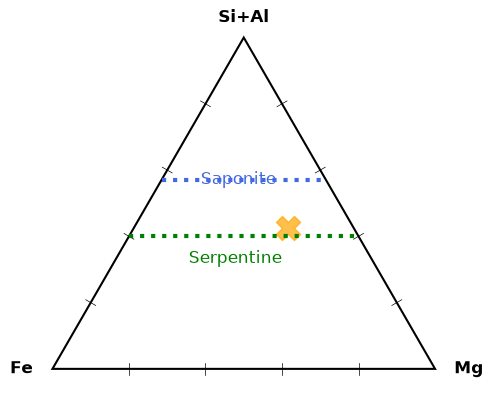

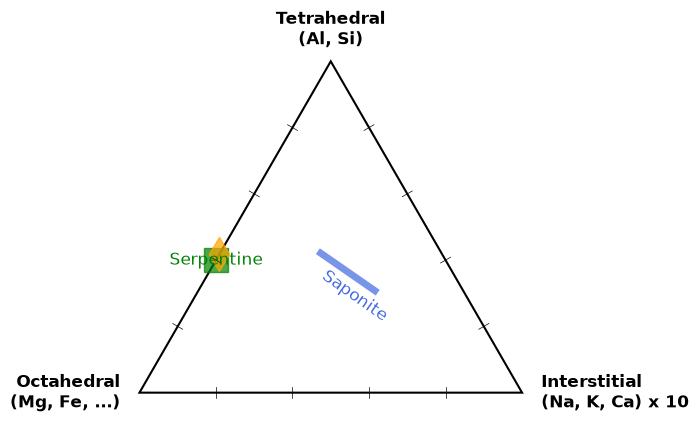

Input data:
Element           Counts
O              50000.000
Mg             35000.000
Si             40000.000
Mn              1500.000
Fe             20000.000
Ni               800.000
Total:        147300.000

Arbitrary Absorption Correction used: Titan Detector Window
k-factors used: Titan 80 keV
Absorption Correction: -25.000000 nm*g/cm3
Takeoff angle: 18.00 degrees
Oxygen determined by stoichiometry

Quantification results:
Element       At%      Wt%  Ox Wt %  Valence k-factor
O          58.641   41.602    0.000    0.000    1.130
Mg         16.274   17.539   29.084    2.000    0.919
Si         17.283   21.523   46.045    4.000    1.000
Mn          0.512    1.248    1.612    2.000    1.555
Fe          6.991   17.311   22.271    2.000    1.618
Ni          0.299    0.777    0.989    2.000    1.817

--- Sheet Silicate Ternary Diagrams ---

Tet/Oct atoms = 0.72 
Tet/Oct atoms = 0.66 ideal serpentine
Tet/Oct atoms = 1.33 ideal saponite

Serpentine calculation:
Ideal formula: Oct6 Tet4 

In [9]:
options_step5 = core.AnalysisOptions(
    kfactors='Titan 80 keV',
    absorption_correction=-0.025,
    arbitrary_absorption='Titan Detector Window',
    takeoff=18.0,
    phase_analysis='Sheet Silicate Ternary'
)
result5 = core.run_analysis(analysis_input, options=options_step5)

print(result5.report_text)

In [10]:
# The two ternary diagrams were created by the phase analysis plugin via plt.show() above
# and rendered inline by Jupyter.
print('Ternary diagrams rendered above via the phase analysis plugin.')

# Parse phase analysis tables as DataFrames
phase_tables5 = [t for t in result5.tables if t.name.startswith('phase_analysis_')]

for table in phase_tables5:
    print(f'\n### {table.title}')
    df_phase = pd.DataFrame(table.rows, columns=table.columns)
    display(df_phase)


Ternary diagrams rendered above via the phase analysis plugin.

### Sheet Silicate Ternary Numeric Results


,metric,value,note
0,Tet/Oct atoms,0.72,
1,Tet/Oct atoms,0.66,ideal serpentine
2,Tet/Oct atoms,1.33,ideal saponite
3,Tet atoms,17.28,at% (ideal 14.285%)
4,Oct atoms,24.08,at% (ideal 21.429%)
5,Oxygen atoms,58.64,at% (ideal 64.286%)
6,Tet + Oct + Interstitial atoms,41.36,at%
7,O,58.64,at%
8,Unaccounted non-H atoms (100%-Tet+Oct+Inter+O),0.00,at%



### Sheet Silicate Ternary - Oxygen At% for variable interstitial H2O


,label,value
0,O by stoichiometry on,60.27



### Sheet Silicate Ternary - O by stoichiometry off


,label,value
0,0 H2O,62.34
1,1 H2O,64.20
2,2 H2O,65.88
3,3 H2O,67.42
4,4 H2O,68.82


## 9. Summary

Each step adds a layer of physical correction to the quantification:

| Step | Corrections Applied | Purpose |
|------|--------------------|---------|
| 1 | K-factors (Titan 80 keV) | Convert raw counts to elemental abundances |
| 2 | + Thickness (-0.025 g/cm²), takeoff 18° | Account for thin-film X-ray absorption in the specimen |
| 3 | + Arbitrary absorption (Titan Detector Window) | Account for X-ray absorption in the detector window/filter |
| 4 | + Serpentine phase analysis | Calculate mineral-specific cation ratios and site occupancies |
| 5 | + Sheet Silicate Ternary diagrams | Visualize composition in ternary space with serpentine/saponite references |

**Note on H inference:** Hydrogen is invisible in TEM-EDS. The Serpentine phase analysis infers H from O stoichiometry using the 4/9 ratio (4 OH per 5 O in the formula Mg₃Si₂O₅(OH)₄). The effective formula is Oct₃ Tet₂ O₉ H₄ = Oct₃ Tet₂ O₅(OH)₄ (per 18 non-H atoms, 28 total atoms including H).

**Note:** All corrections can be combined in a single `run_analysis` call (as shown in Steps 4 and 5). The stepwise approach above demonstrates the individual contribution of each correction layer.